**References:**

- https://keras.io/examples/rl/ppo_cartpole/
- [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)
- [OpenAI Spinning Up docs - PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html)
- [OpenAI Spinning Up Github - PPO](https://github.com/openai/spinningup/blob/master/spinup/algos/tf1/ppo/ppo.py)
- https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py
- L. Bantel, P. Domanski and D. Pflüger, "High-Fidelity Simulation of a Cartpole for Sim-to-Real Deep Reinforcement Learning," 2024 4th Interdisciplinary Conference on Electrics and Computer (INTCEC), Chicago, IL, USA, 2024, pp. 1-6, doi: https://doi.org/10.1109/INTCEC61833.2024.10602859.
- https://github.com/SC-SGS/High-Fidelity-Cartpole

In [6]:
import warnings

In [7]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import tensorflow as tf
#from tf import keras as keras
import keras
from keras import layers

import numpy as np
import gym
import scipy.signal

In [8]:
np.seterr(all="ignore")

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [9]:
import matplotlib, cv2
import matplotlib.pyplot as plt
import base64, io, os, time
import IPython, functools
#from tqdm import tqdm
import tensorflow_probability as tfp
import math
from typing import Optional
from gym import spaces, logger
from gym.utils import seeding

In [10]:
warnings.filterwarnings("ignore", message=".*Conversion of an array with ndim > 0 to a scalar.*")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Functions and class

In [11]:
class CartPoleEnvCustomized_with_pid(gym.Env):
    """
    ### Description
    This environment corresponds to the version of the cart-pole problem
    described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    A pole is attached by an un-actuated joint to a cart, which moves along a
    frictionless track. The pendulum starts upright, and the goal is to prevent
    it from falling over by increasing and reducing the cart's velocity.
    ### Action Space
    The agent take a 1-element vector for actions.
    The action space is `(action)` in `[0, 1]`, where `action` is used to push
    the cart with a fixed amount of force:
    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push cart to the left  |
    | 1   | Push cart to the right |
    Note: The amount the velocity is reduced or increased is not fixed as it depends on the angle the pole is pointing.
    This is because the center of gravity of the pole increases the amount of energy needed to move the cart underneath it
    ### Observation Space
    The observation is a `ndarray` with shape `(4,)` where the elements correspond to the following:
    | Num | Observation           | Min                  | Max                |
    |-----|-----------------------|----------------------|--------------------|
    | 0   | Cart Position         | -4.8*                 | 4.8*                |
    | 1   | Cart Velocity         | -Inf                 | Inf                |
    | 2   | Pole Angle            | ~ -0.418 rad (-24°)** | ~ 0.418 rad (24°)** |
    | 3   | Pole Angular Velocity | -Inf                 | Inf                |
    **Note:** above denotes the ranges of possible observations for each element, but in two cases this range exceeds the
    range of possible values in an un-terminated episode:
    - `*`: the cart x-position can be observed between `(-4.8, 4.8)`, but an episode terminates if the cart leaves the
    `(-2.4, 2.4)` range.
    - `**`: Similarly, the pole angle can be observed between  `(-.418, .418)` radians or precisely **±24°**, but an episode is
    terminated if the pole angle is outside the `(-.2095, .2095)` range or precisely **±12°**
    ### Rewards
    Reward is 1 for every step taken, including the termination step. The threshold is 475 for v1.
    ### Starting State
    All observations are assigned a uniform random value between (-0.05, 0.05)
    ### Episode Termination
    The episode terminates of one of the following occurs:
    1. Pole Angle is more than ±12°
    2. Cart Position is more than ±2.4 (center of the cart reaches the edge of the display)
    3. Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    """

    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 50}

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02  # seconds between state updates
        self.kinematics_integrator = "euler"


        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.viewer = None
        self.state = None

        self.steps_beyond_done = None

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        '''add ElectricalDCMotorEnv to the CartPole class
        and assign values to
        Resistor_R, inductor_L, torque_const_Kt and bemf_const_Ke'''
        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau = self.tau
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0

        self.ideal_env = False
        ####


    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg

        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag #+/-10N
        torque_wanted = force*self.DCMotor_radius

        ### Customization changes #####
        ''' set current refrence value current_ref and
        caclulate actual applied force F based DC motor model and PID control at
        DCMotorModel.step function
        '''
        if self.ideal_env:
          torque_actual = torque_wanted
        else:
          current_ref = torque_wanted/self.DCMotorModel.torque_const_Kt
          #F = self.DCMotorModel.step(current_ref = current_ref,x_dot = x_dot)
          torque_actual = self.DCMotorModel.step(current_ref = current_ref,
                                   x_dot = x_dot/self.DCMotor_radius)
        F = torque_actual/self.DCMotor_radius
        #F = force #ideal env
        ###

        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf
        temp = (
            F + self.polemass_length * theta_dot ** 2 * sintheta
        ) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

        if self.kinematics_integrator == "euler":
            x = x + self.tau * x_dot
            x_dot = x_dot + self.tau * xacc
            theta = theta + self.tau * theta_dot
            theta_dot = theta_dot + self.tau * thetaacc
        else:  # semi-implicit euler
            x_dot = x_dot + self.tau * xacc
            x = x + self.tau * x_dot
            theta_dot = theta_dot + self.tau * thetaacc
            theta = theta + self.tau * theta_dot

        self.state = (x, x_dot, theta, theta_dot)

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
        )

        if not done: # if we inside the valid range
            reward = 1.0

        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0

        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.state, dtype=np.float32), reward, done, {} ,torque_wanted, torque_actual


    def reset(self, return_info = False, options = None):
        #super().reset(seed=seed)
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))
        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0
        self.steps_beyond_done = None

        if not return_info:
            return np.array(self.state, dtype=np.float32)
        else:
            return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        screen_width = 600
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        carty = 100  # TOP OF CART
        polewidth = 10.0
        polelen = scale * (2 * self.length)
        cartwidth = 50.0
        cartheight = 30.0

        if self.viewer is None:
            #from gym.utils import pyglet_rendering
            from gym.envs.classic_control import rendering as pyglet_rendering

            self.viewer = pyglet_rendering.Viewer(screen_width, screen_height)
            l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
            axleoffset = cartheight / 4.0
            cart = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            self.carttrans = pyglet_rendering.Transform()
            cart.add_attr(self.carttrans)
            self.viewer.add_geom(cart)
            l, r, t, b = (
                -polewidth / 2,
                polewidth / 2,
                polelen - polewidth / 2,
                -polewidth / 2,
            )
            pole = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            pole.set_color(0.8, 0.6, 0.4)
            self.poletrans = pyglet_rendering.Transform(translation=(0, axleoffset))
            pole.add_attr(self.poletrans)
            pole.add_attr(self.carttrans)
            self.viewer.add_geom(pole)
            self.axle = pyglet_rendering.make_circle(polewidth / 2)
            self.axle.add_attr(self.poletrans)
            self.axle.add_attr(self.carttrans)
            self.axle.set_color(0.5, 0.5, 0.8)
            self.viewer.add_geom(self.axle)
            self.track = pyglet_rendering.Line((0, carty), (screen_width, carty))
            self.track.set_color(0, 0, 0)
            self.viewer.add_geom(self.track)

            self._pole_geom = pole

        if self.state is None:
            return None

        # Edit the pole polygon vertex
        pole = self._pole_geom
        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )
        pole.v = [(l, b), (l, t), (r, t), (r, b)]

        x = self.state
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        self.carttrans.set_translation(cartx, carty)
        self.poletrans.set_rotation(-x[2])

        return self.viewer.render(return_rgb_array=mode == "rgb_array")

    def close(self):
        if self.viewer:
            self.viewer.close()
            self.viewer = None

In [12]:
import math
from math import pi, cos, sin, trunc, e
from typing import Optional, Union
import gin

import numpy as np
import pygame
from pygame import gfxdraw

import gym
from gym import spaces, logger
from gym.utils import seeding

#@gin.configurable
class HighFidelityCartPoleEnvCustomized_with_pid(gym.Env[np.ndarray, Union[int, np.ndarray]]):

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self,
                 force_steps = [0,2,5,7,10,15,20],#[0,5,10,15,20],# [0,100,150,200,250]
                 masscart = 0.94,
                 masspole = 0.1,
                 length = 0.1778,
                 force_mag = 3.0,
                 internal_tau = 0.02,
                 tau = 0.02,
                 x_threshold = 0.3,
                 pole_resistance = 0.99,
                 cart_resistance = 0.99,
                 force_curve = [0,1,0],
                 evaluation = False,#False,
                 swingup = False,#False,
                 discrete_state = False,
                 action_in_state = False): #action_in_state=True

        #set "evaluation" in the code to obtain a second environment for evaluation,
        #for conistent resets

        #physical parameters
        self.force_steps = force_steps
        self.gravity = 9.8
        self.masscart = masscart
        self.masspole = masspole
        self.total_mass = self.masspole + self.masscart
        self.length = length  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag_mean = force_mag
        self.force_mag = None
        self.internal_tau = internal_tau # seconds for euler step
        self.tau = tau  # seconds between state updates, multiple of internal tau
        self.mean_pole_resistance = e**(pole_resistance*internal_tau)
        self.mean_cart_resistance = cart_resistance
        self.cart_resistance = None
        self.pole_resistance = None
        self.force_curve = force_curve

        #different experimental setups
        self.evaluation = evaluation
        self.swingup = swingup
        self.action_in_state = action_in_state
        self.discrete_state = discrete_state

        self.states = []


        # Angle at which to fail the classical task
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = x_threshold

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                pi,
                np.finfo(np.float32).max
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(len(self.force_steps) * 2 - 1)


        #action within state
        if self.action_in_state:
            action = np.ones(len(force_steps)*2+1)
            self.observation_space = spaces.Box(np.concatenate((-high, action*0)), np.concatenate((high, action)), dtype=np.float32)
            print('action_in_state = True')
        else:
            self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.screen = None
        self.clock = None
        self.isopen = True
        self.state = None
        self.num_steps = None

        self.steps_beyond_done = None

        self.last_action = None
        self.last_reward = 0

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        '''add ElectricalDCMotorEnv to the CartPole class
        and assign values to
        Resistor_R, inductor_L, torque_const_Kt and bemf_const_Ke'''
        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau = self.tau
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0

        self.ideal_env = False
        ####



    def update_state(self, state, force, tau):
        #function implements the actual differential equation and integration

        x, x_dot, theta, theta_dot = state

        costheta = math.cos(theta)
        sintheta = math.sin(theta)

        # For the interested reader:
        # https://coneural.org/florian/papers/05_cart_pole.pdf

        #sign function can lead to weird results depending on the time-step-width
        #possible replacement is a scaled and parameterized sigmoid

        temp = (
            force + self.polemass_length * theta_dot ** 2 * sintheta
            - self.cart_resistance*np.tanh(x_dot*tau)#sign(x_dot)
        ) / self.total_mass

        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
        )

        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass



        x_dot = x_dot + tau * xacc
        x = x + tau * x_dot
        theta_dot = theta_dot*self.pole_resistance + tau * thetaacc
        theta = theta + tau * theta_dot


        theta = angle_normalize(theta)


        return (x, x_dot, theta, theta_dot)



    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg
        assert self.state is not None, "Call reset before using step method."


        action = action - len(self.force_steps) + 1



        if action > 0:
            dir = 1
        elif action < 0:
            dir = -1
        else:
            dir = 0


        #motor values to use (0-255)
        force = self.force_steps[abs(action)]


        #force curve of the cartpole
        force = self.force_curve[0]*force**2 - self.force_curve[1]*force +  self.force_curve[2]
        force *= dir

        torque_wanted=force*self.DCMotor_radius
        # ,torque_wanted, torque_actual
        x, x_dot, theta, theta_dot = self.state

        if self.discrete_state:
            old_disc_theta = discretize_angle(theta)


        #internal finer stepping of the simulation
        for i in range(int(self.tau/self.internal_tau)):
          if self.ideal_env:
            torque_actual = torque_wanted
          else:
            current_ref = torque_wanted/self.DCMotorModel.torque_const_Kt
            #F = self.DCMotorModel.step(current_ref = current_ref,x_dot = x_dot)
            torque_actual = self.DCMotorModel.step(current_ref = current_ref,
                                   x_dot = x_dot/self.DCMotor_radius)
          F = torque_actual/self.DCMotor_radius
          self.state = self.update_state(self.state, F, self.internal_tau)
          x, x_dot, theta, theta_dot = self.state



        x, x_dot, theta, theta_dot = self.state

        #calculating the derivatives of the discrete state for the output
        if self.discrete_state:
            new_disc_theta = discretize_angle(theta)

            if new_disc_theta > pi/2 and old_disc_theta < -pi/2:
                old_disc_theta += 2*pi
            elif new_disc_theta < -pi/2 and old_disc_theta > pi/2:
                old_disc_theta -= pi

            disc_theta_dot = (new_disc_theta - old_disc_theta)/self.tau
            out_state = (x, x_dot, new_disc_theta, disc_theta_dot)
        else:
            out_state = self.state


        #variable to check, if pole is upright
        if abs(theta) < self.theta_threshold_radians:
            self.swingup_done = True
        elif abs(theta) > self.theta_threshold_radians:
            self.swingup_done = False


        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or abs(theta_dot) > 5*pi
            or (abs(theta) > self.theta_threshold_radians and not self.swingup)
        )

        if not done:
            if self.evaluation:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            else:
                reward = cos(theta / 2) * (1-abs(x)/self.x_threshold)
            #additional addon for training swingup faster

            if self.swingup and abs(theta) < 5/180*pi:
                reward += 5
                if abs(theta_dot) < 6/180*pi:
                    reward += 5


        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 0
        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0


        self.num_steps += 1
        self.last_action = action
        self.last_reward = reward

        #append action to state if neccessary
        if self.action_in_state:
            action_arr = np.zeros(len(self.force_steps)*2+1)
            action_arr[action+len(self.force_steps)] = 1
            return np.concatenate((np.array(out_state, dtype=np.float32), action_arr)), reward, done, {} ,torque_wanted, torque_actual
        else:
            return np.array(out_state, dtype=np.float32), reward, done, {} ,torque_wanted, torque_actual


    def reset(
        self,
        *,
        seed: Optional[int] = None,
        return_info: bool = False,
        options: Optional[dict] = None,
    ):
        super().reset(seed=seed)

        #reset with slight perturbation
        self.state = self.np_random.uniform(low=-0.1, high=0.1, size=(4,))
        #vertical
        self.state[2] = self.np_random.uniform(low = -2/180*pi, high = 2/180*pi)

        if self.swingup:

            #for evaluation purposes start always hanging
            #for training, start with an arbitary pole angle
            if self.evaluation:
                self.state = self.np_random.uniform(low=-0.01, high=0.01, size=(4,))
                self.state[2] = angle_normalize(pi - self.np_random.uniform(low=-0.01, high=0.01))
            else:
                self.state[2] = self.np_random.uniform(low=-pi, high=pi)


        #perturbate resistance parameters
        self.cart_resistance = self.mean_cart_resistance#np.random.uniform(low = self.mean_cart_resistance*0.95, high = self.mean_cart_resistance*1.05)
        self.pole_resistance = self.mean_pole_resistance#np.random.uniform(low = self.mean_pole_resistance*0.97, high = min(self.mean_pole_resistance*1.03,0.9999))



        #used to train for multiple poles on one agent
        """"
        pend = self.np_random.randint(2)d

        if pend == 0:

            self.masspole = 0.127
            self.total_mass = self.masspole + self.masscart
            self.length = 0.1778  # actually half the pole's length
            self.polemass_length = self.masspole * self.length

        else:

            self.masspole = 0.23
            self.total_mass = self.masspole + self.masscart
            self.length = 0.3302  # actually half the pole's length
            self.polemass_length = self.masspole * self.length
        """


        self.num_steps = 0
        self.steps_beyond_done = None
        self.last_action = 0
        self.swingup_done = False

        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0

        if self.action_in_state:
            action = np.zeros(len(self.force_steps)*2+1)
            out = np.concatenate((np.array(self.state, dtype=np.float32), action))
        else:
            out = np.array(self.state, dtype=np.float32)

        if not return_info:
            return out
        else:
            return out, {}




    def render(self, mode="human"):
        screen_width = 608
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        polewidth = 10.0
        polelen = scale * self.length
        cartwidth = 50.0
        cartheight = 30.0

        if self.state is None:
            return None

        x = self.state

        if self.screen is None:
            pygame.init()
            self.screen = pygame.display.set_mode((screen_width, screen_height))
        if self.clock is None:
            self.clock = pygame.time.Clock()

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))

        fontObj = pygame.font.Font(None, 32)
        cart_res = fontObj.render(str(self.cart_resistance), True, (0,0,0), None)

        l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
        axleoffset = cartheight / 4.0
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        carty = int(screen_height/2 + cartheight/2)  # TOP OF CART
        cart_coords = [(l, b), (l, t), (r, t), (r, b)]
        cart_coords = [(c[0] + cartx, c[1] + carty) for c in cart_coords]
        gfxdraw.aapolygon(self.surf, cart_coords, (0, 0, 0))
        gfxdraw.filled_polygon(self.surf, cart_coords, (0, 0, 0))

        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )

        pole_coords = []
        for coord in [(l, b), (l, t), (r, t), (r, b)]:
            coord = pygame.math.Vector2(coord).rotate_rad(-x[2])
            coord = (coord[0] + cartx, coord[1] + carty + axleoffset)
            pole_coords.append(coord)
        gfxdraw.aapolygon(self.surf, pole_coords, (202, 152, 101))
        gfxdraw.filled_polygon(self.surf, pole_coords, (202, 152, 101))

        gfxdraw.aacircle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )
        gfxdraw.filled_circle(
            self.surf,
            int(cartx),
            int(carty + axleoffset),
            int(polewidth / 2),
            (129, 132, 203),
        )

        gfxdraw.hline(self.surf, 0, screen_width, carty, (0, 0, 0))

        #draw force steps in render
        for i in range(-len(self.force_steps), len(self.force_steps)+1):
            color = (0,0,0)
            if i == self.last_action:
                color = (255,0,0)
            gfxdraw.filled_circle(
                    self.surf,
                    int(screen_width/2+i*20),
                    int(50),
                    5,
                    color,
            )

        #reward value
        gfxdraw.rectangle(self.surf, (20,20,20,80),(0,0,0))

        gfxdraw.box(self.surf, (20,20,20,self.last_reward*80),(0,0,0))


        self.surf = pygame.transform.flip(self.surf, False, True)
        self.screen.blit(self.surf, (0, 0))
        if mode == "human":
            self.clock.tick(self.metadata["render_fps"])
            pygame.display.flip()

        if mode == "rgb_array":
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )
        else:
            return self.isopen

    def close(self):
        if self.screen is not None:
            pygame.quit()
            self.isopen = False


def angle_normalize(x):
    return ((x + np.pi) % (2 * np.pi)) - np.pi



#not used, possible distribution for perturbating physical parameters
def trunc_normal(mean, sigma, lower = 0, upper = 1):
    i = 0
    x = mean

    while i < 50:
        x =  np.random.normal(mean, sigma)
        if x >= lower and x <= upper:
            break
        i += 1

    if i >= 50:
        x = mean

    return x


def discretize_angle(theta):
    disc = int((theta+pi)/pi*2048)-2048 #range from -2048 to 2048
    return disc/2048*pi #range from -pi to pi


def sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

def sigmoid(x,tau):
    return 2/(1 + np.exp(-x*tau))-1

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [13]:
class ElectricalDCMotorEnv():

      def __init__(self):
        self.Resistor_R = 1.0
        self.inductor_L = 0.1
        self.torque_const_Kt = 1.0
        self.bemf_const_Ke = 1.0
        self.tau = 0.02
        #

        self.Kp = 4.3 #5.0 #50.0
        self.Ki = 1.0 #10.0 #3.0
        self.Kd = 10.0**(-6)
        self.aL=10.0**(-3) #Low pass parameter
        self.aH = 10.0**2 #High pass parameter
        self.Kr = 0.7###
        self.Kw = 1.0

        #
        self.current = 0.0
        self.current_error = 0.0
        self.current_error_acc = 0.0
        self.current_error_prev = 0.0
        self.voltage_input = 0.0
        self.xdot = 0.0
        self.PID_Discretization = "Simple" #"Backward", " "Bilinear" , "Forward" "Simple"


      def step(self, current_ref, x_dot):
        aL = self.aL
        aH = self.aH
        self.current_error = current_ref-self.current
        delta_error = self.current_error-self.current_error_prev

        if self.PID_Discretization == "Simple":
          self.current_error_acc += self.current_error*self.tau
          HP_delta_error = delta_error

        elif self.PID_Discretization == "Backward":
          self.current_error_acc = (self.current_error_acc+(self.current_error)*self.tau)/(1+aL*self.tau) #Low Pass
          HP_delta_error = (self.current_error + aH*delta_error)/(1+aL*self.tau)#High Pass

        elif self.PID_Discretization == "Bilinear":
          error_avg = (self.current_error+self.current_error_prev)/2
          self.current_error_acc =  ((1-aL*self.tau/2)*self.current_error_acc + error_avg*self.tau)/(1+aL*self.tau/2)#Low Pass
          HP_delta_error =  ((1-aL*self.tau/2)*self.current_error + aH*delta_error)/(1+aL*self.tau/2)#High Pass

        else:
          self.current_error_acc = (1-aL*self.tau)*self.current_error_acc+(self.current_error_prev)*self.tau #Low Pass
          HP_delta_error = (1-aH*self.tau)*self.current_error + aH*delta_error #High Pass

        P = self.Kp*self.current_error
        I = self.Ki*self.current_error_acc
        D = self.Kd*HP_delta_error/self.tau
        voltage_BEMF = x_dot*self.bemf_const_Ke
        voltage_input = P+I+D+self.Kr*current_ref+self.Kw*x_dot
        voltage_input = np.clip(voltage_input, -20, 20)

        self.current_error_prev = 0+self.current_error
        self.current += self.tau*(voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
        self.voltage_input = voltage_input
        self.xdot = x_dot
        F=self.torque_const_Kt*self.current

        return F # return applied torque

In [14]:

def discounted_cumulative_sums(x, discount):
    # Discounted cumulative sums of vectors for computing rewards-to-go and advantage estimates
    return scipy.signal.lfilter([1], [1, float(-discount)], x[::-1], axis=0)[::-1]


class Buffer:
    # Buffer for storing trajectories
    def __init__(self, observation_dimensions, size, gamma=0.99, lam=0.95):
        # Buffer initialization
        self.observation_buffer = np.zeros(
            (size, observation_dimensions), dtype=np.float32
        )
        self.action_buffer = np.zeros(size, dtype=np.int32)
        self.advantage_buffer = np.zeros(size, dtype=np.float32)
        self.reward_buffer = np.zeros(size, dtype=np.float32)
        self.return_buffer = np.zeros(size, dtype=np.float32)
        self.value_buffer = np.zeros(size, dtype=np.float32)
        self.logprobability_buffer = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.pointer, self.trajectory_start_index = 0, 0

    def store(self, observation, action, reward, value, logprobability):
        # Append one step of agent-environment interaction
        self.observation_buffer[self.pointer] = observation
        self.action_buffer[self.pointer] = action
        self.reward_buffer[self.pointer] = reward
        self.value_buffer[self.pointer] = value
        self.logprobability_buffer[self.pointer] = logprobability
        self.pointer += 1

    def finish_trajectory(self, last_value=0):
        # Finish the trajectory by computing advantage estimates and rewards-to-go
        path_slice = slice(self.trajectory_start_index, self.pointer)
        rewards = np.append(self.reward_buffer[path_slice], last_value)
        values = np.append(self.value_buffer[path_slice], last_value)

        deltas = rewards[:-1] + self.gamma * values[1:] - values[:-1]

        self.advantage_buffer[path_slice] = discounted_cumulative_sums(
            deltas, self.gamma * self.lam
        )
        self.return_buffer[path_slice] = discounted_cumulative_sums(
            rewards, self.gamma
        )[:-1]

        self.trajectory_start_index = self.pointer

    def get(self):
        # Get all data of the buffer and normalize the advantages
        self.pointer, self.trajectory_start_index = 0, 0
        advantage_mean, advantage_std = (
            np.mean(self.advantage_buffer),
            np.std(self.advantage_buffer),
        )
        self.advantage_buffer = (self.advantage_buffer - advantage_mean) / advantage_std
        return (
            self.observation_buffer,
            self.action_buffer,
            self.advantage_buffer,
            self.return_buffer,
            self.logprobability_buffer,
        )

#output_activation=None
def mlp(x, sizes, activation=keras.activations.tanh,
        output_activation=None):
    # Build a feedforward neural network
    for size in sizes[:-1]:
        x = layers.Dense(units=size, activation=activation)(x)
    return layers.Dense(units=sizes[-1], activation=output_activation)(x)



def logprobabilities(logits, a):
    # Compute the log-probabilities of taking actions a by using the logits (i.e. the output of the actor)
    logprobabilities_all = keras.ops.log_softmax(logits)
    logprobability = keras.ops.sum(
        keras.ops.one_hot(a, num_actions) * logprobabilities_all, axis=1
    )
    return logprobability


seed_generator = keras.random.SeedGenerator(1337)


# Sample action from actor
@tf.function
def sample_action(observation):
    logits = actor(observation)
    action = keras.ops.squeeze(
        keras.random.categorical(logits, 1, seed=seed_generator), axis=1
    )
    return logits, action


# Train the policy by maxizing the PPO-Clip objective
@tf.function
def train_policy(
    observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        ratio = keras.ops.exp(
            logprobabilities(actor(observation_buffer), action_buffer)
            - logprobability_buffer
        )
        min_advantage = keras.ops.where(
            advantage_buffer > 0,
            (1 + clip_ratio) * advantage_buffer,
            (1 - clip_ratio) * advantage_buffer,
        )

        policy_loss = -keras.ops.mean(
            keras.ops.minimum(ratio * advantage_buffer, min_advantage)
        )
    policy_grads = tape.gradient(policy_loss, actor.trainable_variables)
    policy_optimizer.apply_gradients(zip(policy_grads, actor.trainable_variables))

    kl = keras.ops.mean(
        logprobability_buffer
        - logprobabilities(actor(observation_buffer), action_buffer)
    )
    kl = keras.ops.sum(kl)
    return kl


# Train the value function by regression on mean-squared error
@tf.function
def train_value_function(observation_buffer, return_buffer):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        value_loss = keras.ops.mean((return_buffer - critic(observation_buffer)) ** 2)
    value_grads = tape.gradient(value_loss, critic.trainable_variables)
    value_optimizer.apply_gradients(zip(value_grads, critic.trainable_variables))


## Hyperparameters

In [15]:
# Hyperparameters of the PPO algorithm
steps_per_epoch = 4000
steps_per_episode_goal = 500
episodes_max = 2500 #3000
epochs = 60 # 40 #30
gamma = 0.99
clip_ratio = 0.2
policy_learning_rate = 3e-4
value_function_learning_rate = 1e-3
train_policy_iterations = 80
train_value_iterations = 80
lam = 0.97
target_kl = 0.01
hidden_sizes = (64, 64)

# True if you want to render the environment
render = False

## Initializations

In [16]:
# Initialize the environment and get the dimensionality of the
# observation space and the number of possible actions
CartPole = HighFidelityCartPoleEnvCustomized_with_pid #HighFidelityCartPoleEnvCustomized_with_pid #CartPoleEnvCustomized_with_pid
env = CartPole()
observation_dimensions = env.observation_space.shape[0]
num_actions = env.action_space.n

# Initialize the buffer
buffer = Buffer(observation_dimensions, steps_per_epoch)

# Initialize the actor and the critic as keras models
observation_input = keras.Input(shape=(observation_dimensions,), dtype="float32")
logits = mlp(observation_input, list(hidden_sizes) + [num_actions])
actor = keras.Model(inputs=observation_input, outputs=logits)
value = keras.ops.squeeze(mlp(observation_input, list(hidden_sizes) + [1]), axis=1)
critic = keras.Model(inputs=observation_input, outputs=value)

# Initialize the policy and the value function optimizers
policy_optimizer = keras.optimizers.Adam(learning_rate=policy_learning_rate)
value_optimizer = keras.optimizers.Adam(learning_rate=value_function_learning_rate)

# Initialize the observation, episode return and episode length
#observation, _ = env.reset()
observation = env.reset()
episode_return, episode_length = 0, 0

In [17]:
print("observation_dimensions=",observation_dimensions)
print("num_actions=",num_actions)

observation_dimensions= 4
num_actions= 13


In [18]:
print(env.step(3)[0])

[ 0.0280406   0.07900315 -0.03582039 -0.6987807 ]


In [19]:
#actor.summary()

In [20]:
#critic.summary()

## Train

In [21]:
observation = env.reset()
#train_mode = True
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
#env.ideal_env = False
#env.DCMotorModel.Kp = 0.0
#env.DCMotorModel.Ki = 0.0
#env.DCMotorModel.Kd = 0.0
#env.DCMotorModel.Kr = 1.0
#env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
#env.ideal_env = False
#env.DCMotorModel.Kp = 4.3
#env.DCMotorModel.Ki = 1.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.7
#env.DCMotorModel.Kw = 1.0

In [22]:
episode_action_error_abs = 0

In [23]:
avg_reward_list = []
acc_ep_reward_list = []

episode = 0
epoch = 0
# Iterate over the number of epochs/episodes
#while (epoch < epochs) and (episode < episodes_max):
while(episode < episodes_max):
    print(f"Epoch: {epoch}")
    # Initialize the sum of the returns, lengths and number of episodes for each epoch
    episode_return = 0.0
    t = 0
    # Iterate over the steps of each epoch
    #while (t < steps_per_epoch):
    while (t < steps_per_epoch) and (episode < episodes_max):
        if render:
            env.render()

        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        if CartPole == CartPoleEnvCustomized_with_pid:
            x_obs = observation[0]
            reward= reward*(x_obs>-0.1 and x_obs<0.1)
        episode_return += reward

        # Get the value and log-probability of the action
        value_t = critic(observation)
        logprobability_t = logprobabilities(logits, action)
        # Store obs, act, rew, v_t, logp_pi_t
        buffer.store(observation, action, reward, value_t, logprobability_t)
        # Update the observation
        observation = observation_new

        # Finish trajectory if reached to a terminal state
        terminal = done
        if terminal or (t == steps_per_epoch - 1) or ((t+1)%steps_per_episode_goal==0):
            #print(f"Episode: {episode}; Acc. Reward: {episode_return:.2f}")
            acc_ep_reward_list.append(episode_return)
            avg_return = round(np.mean(acc_ep_reward_list[-40:]))
            avg_reward_list.append(avg_return)
            episode_return = 0.0
            episode += 1
        #observation, _ = env.reset()
        if terminal or (t == steps_per_epoch - 1):# not necessarily (t+1)%steps_per_episode_goal==0
            last_value = 0 if done else critic(observation.reshape(1, -1))
            buffer.finish_trajectory(last_value)
            observation = env.reset()
            print(f"Episode: {episode}; Acc. Reward: {avg_return:.1f}; Pole fell: {terminal}")
            #acc_ep_reward_list.append(episode_return)
            #print(f"Episode: {episode} ;Acc. Reward: {episode_return:.1f}")
            #episode_return = 0.0
        t+=1
        #if episode >= episodes_max:
        #  break

    # Get values from the buffer
    (
        observation_buffer,
        action_buffer,
        advantage_buffer,
        return_buffer,
        logprobability_buffer,
    ) = buffer.get()

    # Update the policy and implement early stopping using KL divergence
    for _ in range(train_policy_iterations):
        kl = train_policy(
            observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
        )
        if kl > 1.5 * target_kl:
            # Early Stopping
            break

    # Update the value function
    for _ in range(train_value_iterations):
        train_value_function(observation_buffer, return_buffer)
    epoch+=1


Epoch: 0
Episode: 1; Acc. Reward: 7.0; Pole fell: True
Episode: 2; Acc. Reward: 7.0; Pole fell: True
Episode: 3; Acc. Reward: 9.0; Pole fell: True
Episode: 4; Acc. Reward: 8.0; Pole fell: True
Episode: 5; Acc. Reward: 8.0; Pole fell: True
Episode: 6; Acc. Reward: 7.0; Pole fell: True
Episode: 7; Acc. Reward: 7.0; Pole fell: True
Episode: 8; Acc. Reward: 7.0; Pole fell: True
Episode: 9; Acc. Reward: 7.0; Pole fell: True
Episode: 10; Acc. Reward: 6.0; Pole fell: True
Episode: 11; Acc. Reward: 6.0; Pole fell: True
Episode: 12; Acc. Reward: 7.0; Pole fell: True
Episode: 13; Acc. Reward: 7.0; Pole fell: True
Episode: 14; Acc. Reward: 9.0; Pole fell: True
Episode: 15; Acc. Reward: 9.0; Pole fell: True
Episode: 16; Acc. Reward: 8.0; Pole fell: True
Episode: 17; Acc. Reward: 8.0; Pole fell: True
Episode: 18; Acc. Reward: 8.0; Pole fell: True
Episode: 19; Acc. Reward: 8.0; Pole fell: True
Episode: 20; Acc. Reward: 8.0; Pole fell: True
Episode: 21; Acc. Reward: 8.0; Pole fell: True
Episode: 22; 

In [24]:
low_bound_reward_list = 0
up_bound_reward_list= 500
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)

low_bound_reward_list= 0
up_bound_reward_list= 500


In [25]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [26]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [27]:
norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

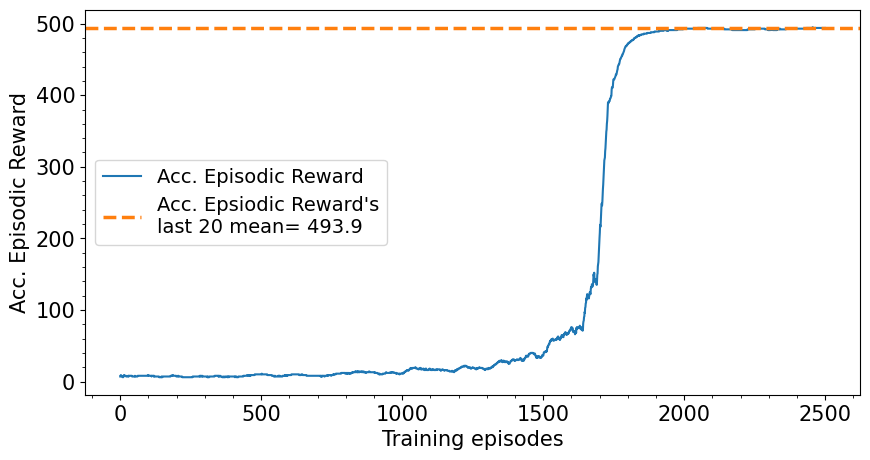

In [28]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's\nlast 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.minorticks_on()
plt.xlabel("Training episodes")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend(fontsize=14)
plt.show()

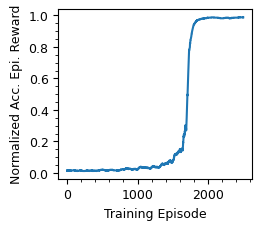

In [29]:
# Episodes versus Avg. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
#plt.xticks(np.arange(0, 2501, 500))
#plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.minorticks_on()
#plt.savefig(path+"Cartpole_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

**One Episode Test limted to 500 time steps**

In [30]:
observation = env.reset()*0
observation[0]=1
save_observation = []
save_wanted_torque = []
save_actual_torque = []

done=False
t=0
while not done and t<501:
    # using our observation, choose an action and take it in the environment
    # Get the logits, action, and take one step in the environment
    observation = observation.reshape(1, -1)
    logits, action = sample_action(observation)
    #observation_new, reward, done, _, _ = env.step(action[0].numpy())
    observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
    observation = observation_new
    save_observation.append(observation)
    save_wanted_torque.append(torque_wanted)
    save_actual_torque.append(torque_actual)
    t+=1

if done:
  print("Pole fell down during test")
else:
  print("Pole NOT fell down during test")

Pole NOT fell down during test


In [31]:
dt=env.tau
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


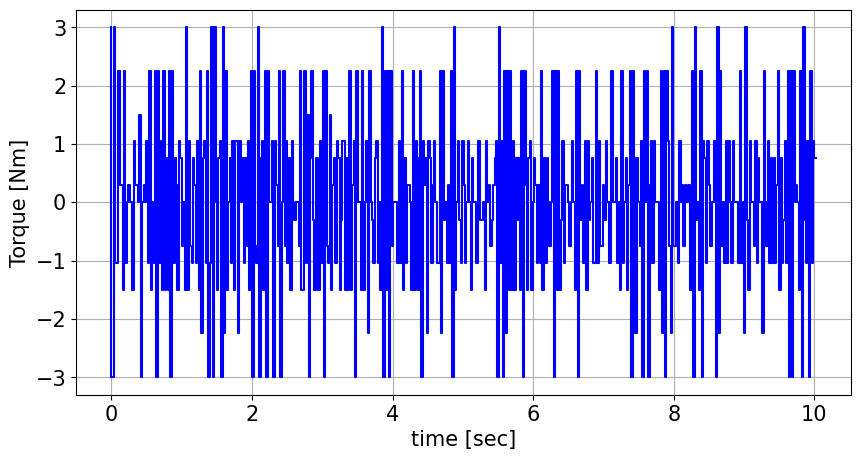

In [32]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [33]:
print(save_wanted_torque)

[3.0, -3.0, -3.0, 3.0, -1.05, -1.05, 2.25, 0.3, 0.3, -1.5, 2.25, -1.05, 0.0, 0.3, 0.0, 0.0, -1.5, 1.05, 0.3, 0.3, 0.0, 1.5, -3.0, 0.0, 0.3, 0.0, 1.05, -1.05, 2.25, -1.5, 0.0, -1.05, 2.25, -3.0, 2.25, -1.05, 1.05, -1.5, 2.25, -1.5, 0.75, -1.5, 2.25, -3.0, 2.25, -1.05, 0.75, 0.3, -1.5, 1.05, 0.75, -0.75, 0.0, -1.5, 3.0, -1.5, 1.05, -0.75, -1.05, 0.75, 0.3, -1.05, 1.05, -1.5, 2.25, -2.25, 0.75, 1.05, -1.05, 2.25, -3.0, -1.05, 3.0, -3.0, 3.0, 0.0, -1.5, 0.75, 1.05, -3.0, 3.0, -2.25, 2.25, -1.5, 0.0, 0.75, -1.05, 1.05, -1.5, 1.05, 1.05, -2.25, 1.05, 0.0, 0.75, -1.05, 0.75, -0.75, 1.05, -1.5, 2.25, -3.0, 2.25, -0.75, -1.05, 3.0, -3.0, 0.75, 1.05, -1.5, 2.25, -3.0, 2.25, 0.0, 0.0, 1.05, -3.0, 1.05, 0.3, -0.75, 2.25, -3.0, 0.0, 2.25, -0.75, 1.05, -1.05, 0.75, -1.5, 1.05, 0.0, -0.3, 0.0, 0.0, -0.75, 2.25, -1.5, -1.5, 2.25, -1.05, 1.5, -3.0, 0.75, 2.25, -0.3, -1.5, 0.75, 0.75, -1.5, 1.05, -1.05, 2.25, -3.0, 2.25, -0.75, -1.05, 1.5, -1.5, 0.3, 0.75, -1.05, 1.05, 0.75, -1.5, -0.3, 1.05, 1.05, -1.5

In [34]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

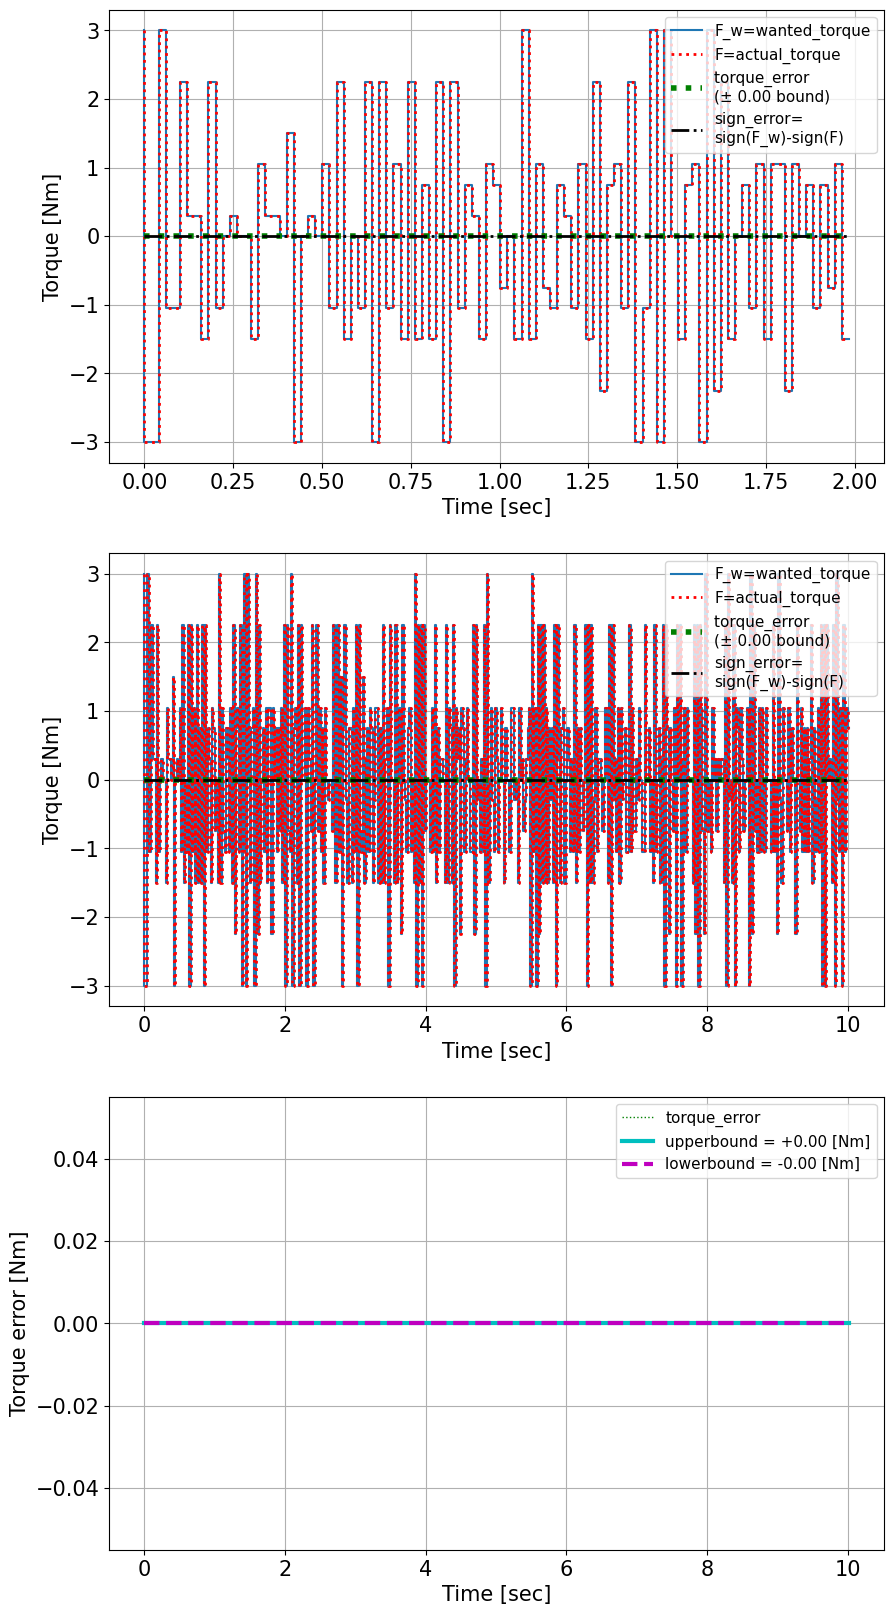

In [35]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(20)

sign_error = np.sign(np.array(save_wanted_torque)) - np.sign(np.array(save_actual_torque))
force_error = np.array(save_wanted_torque) - np.array(save_actual_torque) ### add
force_error_max = np.max(np.abs(force_error))


plt.subplot(3, 1, 1)
plt.step(time_[:int(len(time_)/5)], save_wanted_torque[:int(len(time_)/5)],label = "F_w=wanted_torque")
plt.step(time_[:int(len(time_)/5)], save_actual_torque[:int(len(time_)/5)],':',label = "F=actual_torque",color="red",linewidth = 2)
plt.step(time_[:int(len(time_)/5)], force_error[:int(len(time_)/5)],':',
         label = f"torque_error \n(± {force_error_max:.2f} bound)",
         color="green",linewidth = 4) ### add
plt.step(time_[:int(len(time_)/5)], sign_error[:int(len(time_)/5)],'-.',label = "sign_error=\nsign(F_w)-sign(F)",color="black",linewidth = 2)
plt.legend(fontsize = 11)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Torque [Nm]')

plt.subplot(3, 1, 2)
plt.step(time_, save_wanted_torque,label = "F_w=wanted_torque")
plt.step(time_, save_actual_torque,':',label = "F=actual_torque",color="red",linewidth = 2)
plt.step(time_, force_error,':',
         label = f"torque_error \n(± {force_error_max:.2f} bound)",
         color="green",linewidth = 4) ### add
plt.step(time_, sign_error,'-.',label = "sign_error=\nsign(F_w)-sign(F)",color="black",linewidth = 2)
plt.legend(fontsize = 11)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Torque [Nm]')

plt.subplot(3, 1, 3)
plt.step(time_, force_error,':',
         label = "torque_error",
         color="green",linewidth = 1) ### add
plt.step(time_, force_error*0+force_error_max,'-',
         label = f"upperbound = +{force_error_max:.2f} [Nm]",
         color="c",linewidth = 3) ### add
plt.step(time_, force_error*0-force_error_max,'--',
         label = f"lowerbound = -{force_error_max:.2f} [Nm]",
         color="m",linewidth = 3) ### add
plt.xlabel('Time [sec]')
plt.ylabel('Torque error [Nm]')
plt.legend(fontsize = 11)
plt.grid()

plt.show()

In [36]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

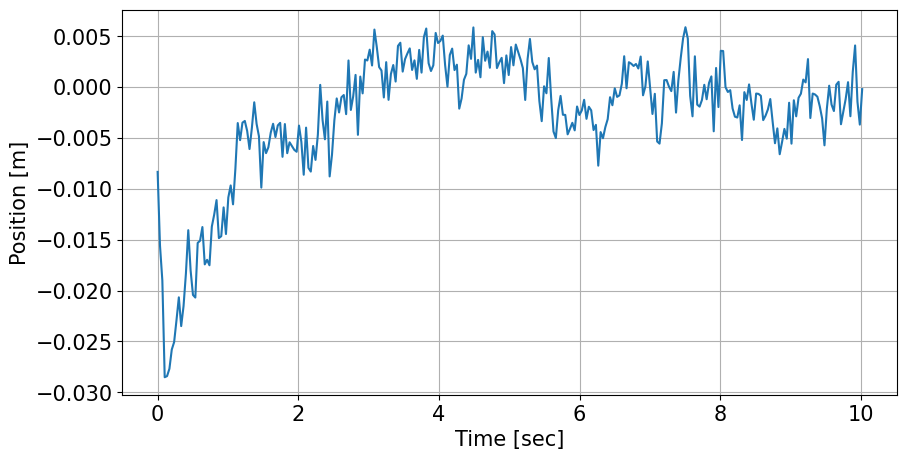

In [37]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [38]:
print(len(position))


501


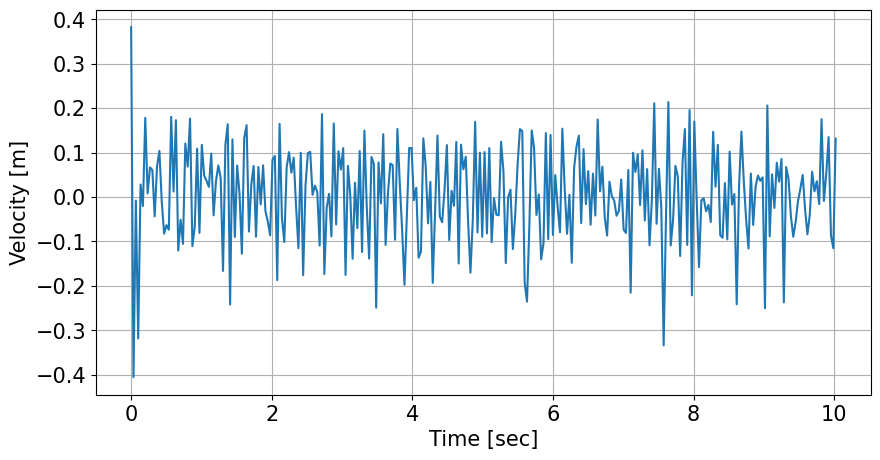

In [39]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

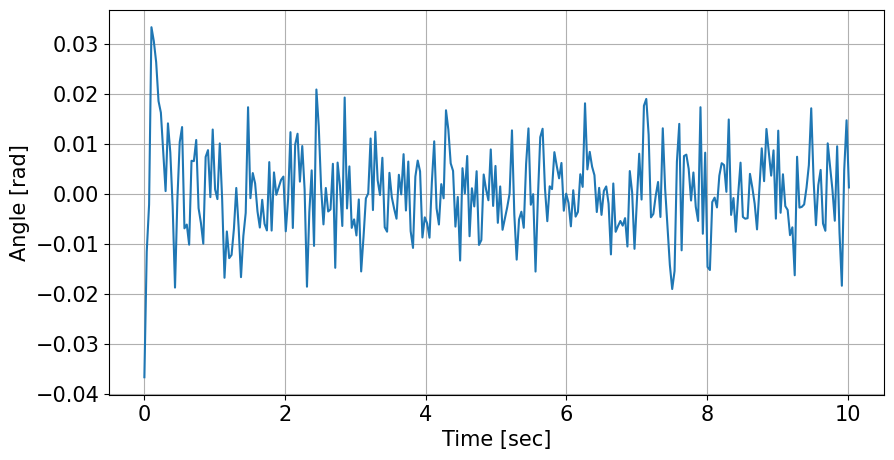

In [40]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

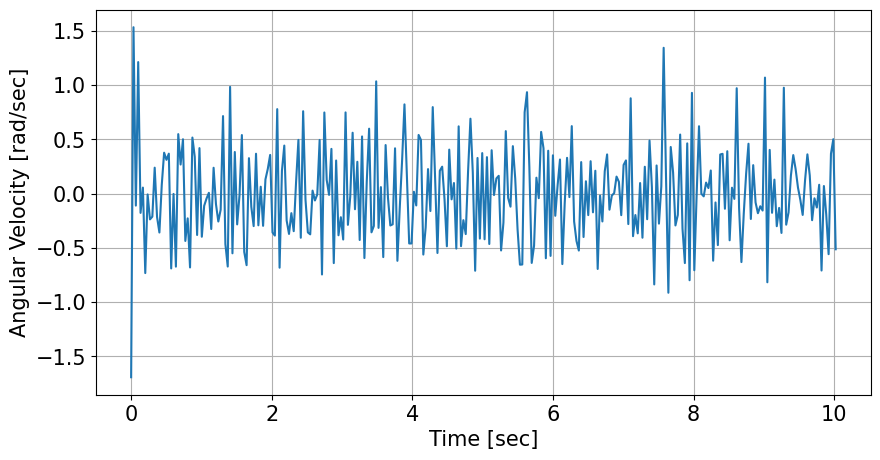

In [41]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Ideal Env**

In [42]:
observation = env.reset()
total_episodes = 100
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
#env.ideal_env = False
#env.DCMotorModel.Kp = 0.0
#env.DCMotorModel.Ki = 0.0
#env.DCMotorModel.Kd = 0.0
#env.DCMotorModel.Kr = 1.0
#env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
#env.ideal_env = False
#env.DCMotorModel.Kp = 4.3
#env.DCMotorModel.Ki = 1.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.7
#env.DCMotorModel.Kw = 1.0

In [43]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []

ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
for ep in range(total_episodes):
  observation = env.reset()
  if ep==total_episodes-1:
    observation*=0
    observation[0]=1
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<501:
      # using our observation, choose an action and take it in the environment
      # Get the logits, action, and take one step in the environment
      observation = observation.reshape(1, -1)
      logits, action = sample_action(observation)
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
      observation = observation_new
      if ep == total_episodes - 1:
        save_observation.append(observation)
        save_wanted_torque.append(torque_wanted)
        save_actual_torque.append(torque_actual)
      t+=1

      episodic_reward += reward
      if not env.ideal_env:
        episodic_abs_error_action += abs(torque_wanted-torque_actual)
        #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
        #n_count+=1


  ep_reward_list.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list[-40:])
  print("Episode * {} * Avg Reward is ==> {}".format(ep, f"{avg_reward:.2f}"))
  avg_reward_list.append(avg_reward)

  if not env.ideal_env:
    ep_abs_error_action_list.append(episodic_abs_error_action/t)
    avg_ep_abs_error = np.mean(ep_abs_error_action_list[-40:])
    print("Episode * {} * Avg Action Abs Error is ==> {}".format(ep, f"{avg_ep_abs_error:.2e}"))
    avg_ep_abs_error_action_list.append(avg_ep_abs_error)

  if done:
    print("Pole fell down during episode")
  else:
    print("Pole NOT fell down during episode")
  num_success+= 0 + (not done)

Episode * 0 * Avg Reward is ==> 486.58
Pole NOT fell down during episode
Episode * 1 * Avg Reward is ==> 489.93
Pole NOT fell down during episode
Episode * 2 * Avg Reward is ==> 488.07
Pole NOT fell down during episode
Episode * 3 * Avg Reward is ==> 487.17
Pole NOT fell down during episode
Episode * 4 * Avg Reward is ==> 488.98
Pole NOT fell down during episode
Episode * 5 * Avg Reward is ==> 488.87
Pole NOT fell down during episode
Episode * 6 * Avg Reward is ==> 489.85
Pole NOT fell down during episode
Episode * 7 * Avg Reward is ==> 490.50
Pole NOT fell down during episode
Episode * 8 * Avg Reward is ==> 489.79
Pole NOT fell down during episode
Episode * 9 * Avg Reward is ==> 489.75
Pole NOT fell down during episode
Episode * 10 * Avg Reward is ==> 489.32
Pole NOT fell down during episode
Episode * 11 * Avg Reward is ==> 489.36
Pole NOT fell down during episode
Episode * 12 * Avg Reward is ==> 489.53
Pole NOT fell down during episode
Episode * 13 * Avg Reward is ==> 489.56
Pole NOT

In [44]:
score = num_success/total_episodes*100
print(f"score=({num_success} successes)/({total_episodes} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


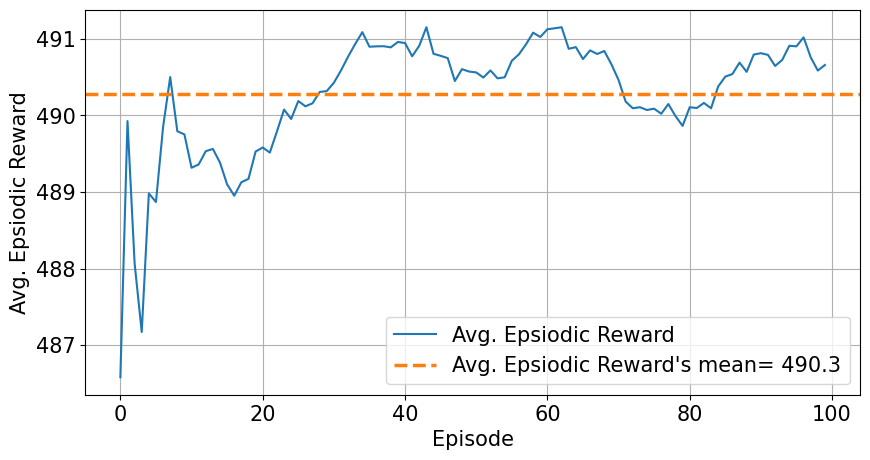

In [45]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [46]:
print("Avg. Epsiodic Reward's mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's mean=
490.2769426080293


In [47]:
dt=env.tau
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


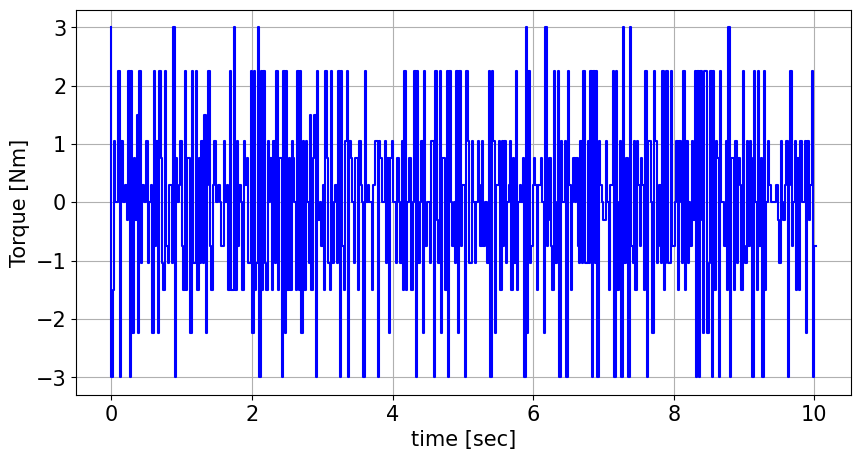

In [48]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [49]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

In [50]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

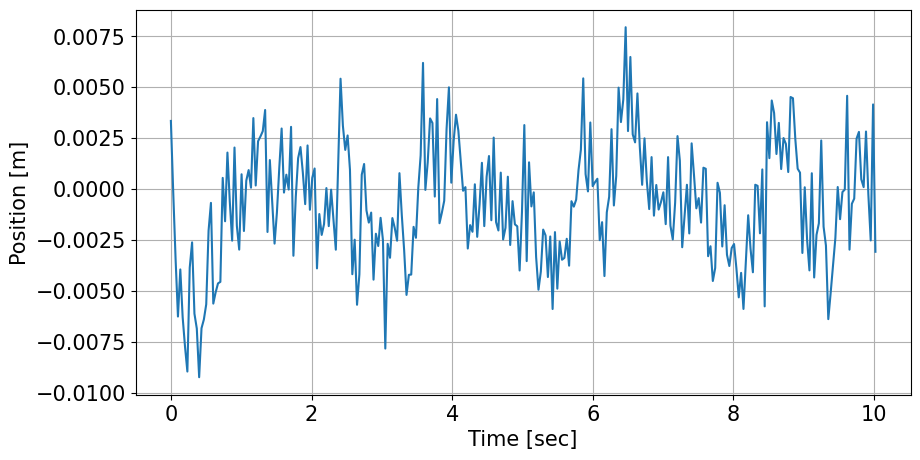

In [51]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [52]:
print(len(position))


501


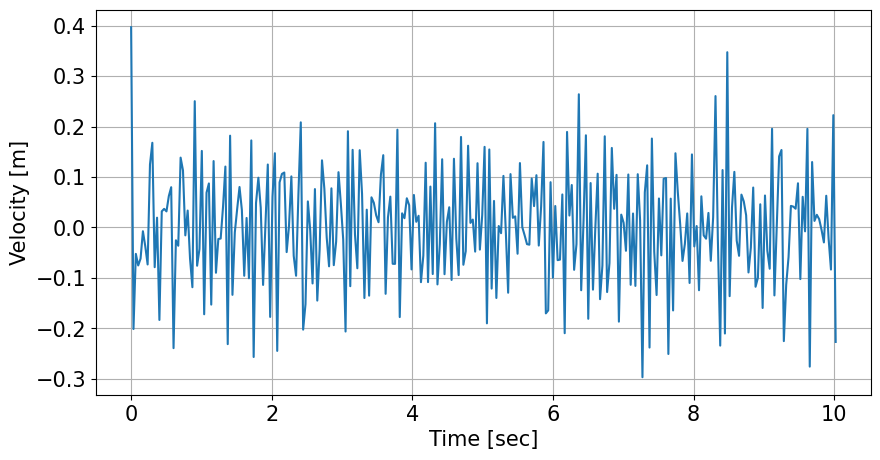

In [53]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

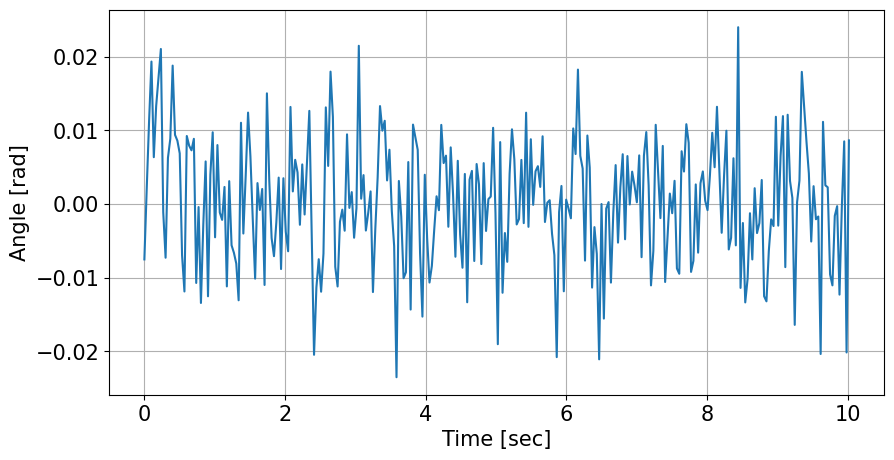

In [54]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

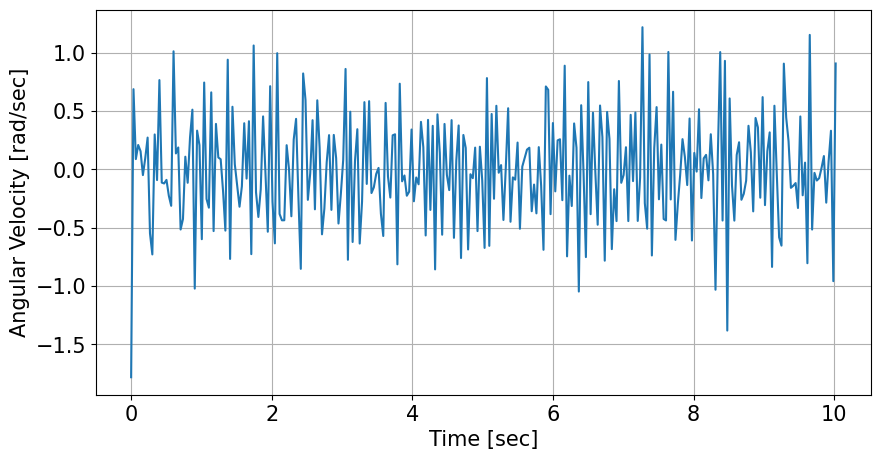

In [55]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env Ctrl**

In [56]:
observation = env.reset()
total_episodes = 100
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
#env.ideal_env = False
#env.DCMotorModel.Kp = 0.0
#env.DCMotorModel.Ki = 0.0
#env.DCMotorModel.Kd = 0.0
#env.DCMotorModel.Kr = 1.0
#env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
env.ideal_env = False
env.DCMotorModel.Kp = 4.3
env.DCMotorModel.Ki = 1.0
env.DCMotorModel.Kd = 10**(-6)
env.DCMotorModel.Kr = 0.7
env.DCMotorModel.Kw = 1.0

In [57]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []

ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
for ep in range(total_episodes):
  observation = env.reset()
  if ep==total_episodes-1:
    observation*=0
    observation[0]=1
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<501:
      # using our observation, choose an action and take it in the environment
      # Get the logits, action, and take one step in the environment
      observation = observation.reshape(1, -1)
      logits, action = sample_action(observation)
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
      observation = observation_new
      if ep == total_episodes - 1:
        save_observation.append(observation)
        save_wanted_torque.append(torque_wanted)
        save_actual_torque.append(torque_actual)
      t+=1

      episodic_reward += reward
      if not env.ideal_env:
        episodic_abs_error_action += abs(torque_wanted-torque_actual)
        #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
        #n_count+=1


  ep_reward_list.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list[-40:])
  print("Episode * {} * Avg Reward is ==> {}".format(ep, f"{avg_reward:.2f}"))
  avg_reward_list.append(avg_reward)

  if not env.ideal_env:
    ep_abs_error_action_list.append(episodic_abs_error_action/t)
    avg_ep_abs_error = np.mean(ep_abs_error_action_list[-40:])
    print("Episode * {} * Avg Action Abs Error is ==> {}".format(ep, f"{avg_ep_abs_error:.2e}"))
    avg_ep_abs_error_action_list.append(avg_ep_abs_error)

  if done:
    print("Pole fell down during episode")
  else:
    print("Pole NOT fell down during episode")
  num_success += 0+(not done)

Episode * 0 * Avg Reward is ==> 483.66
Episode * 0 * Avg Action Abs Error is ==> 8.96e-02
Pole NOT fell down during episode
Episode * 1 * Avg Reward is ==> 487.46
Episode * 1 * Avg Action Abs Error is ==> 9.61e-02
Pole NOT fell down during episode
Episode * 2 * Avg Reward is ==> 490.71
Episode * 2 * Avg Action Abs Error is ==> 9.58e-02
Pole NOT fell down during episode
Episode * 3 * Avg Reward is ==> 489.92
Episode * 3 * Avg Action Abs Error is ==> 9.67e-02
Pole NOT fell down during episode
Episode * 4 * Avg Reward is ==> 489.70
Episode * 4 * Avg Action Abs Error is ==> 9.79e-02
Pole NOT fell down during episode
Episode * 5 * Avg Reward is ==> 489.61
Episode * 5 * Avg Action Abs Error is ==> 9.70e-02
Pole NOT fell down during episode
Episode * 6 * Avg Reward is ==> 488.98
Episode * 6 * Avg Action Abs Error is ==> 9.79e-02
Pole NOT fell down during episode
Episode * 7 * Avg Reward is ==> 489.94
Episode * 7 * Avg Action Abs Error is ==> 9.75e-02
Pole NOT fell down during episode
Episode 

In [58]:
score = num_success/total_episodes*100
print(f"score=({num_success} successes)/({total_episodes} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


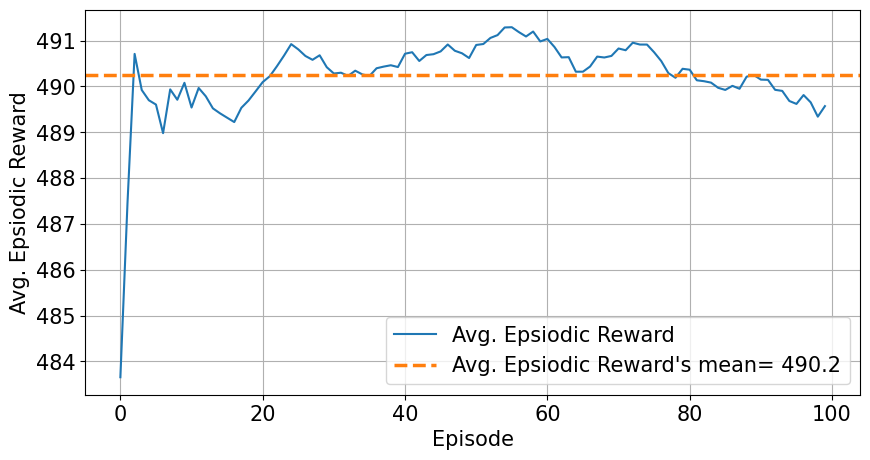

In [59]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [60]:
print("Avg. Epsiodic Reward's  mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's  mean=
490.2443618352521


In [61]:
dt=env.tau
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


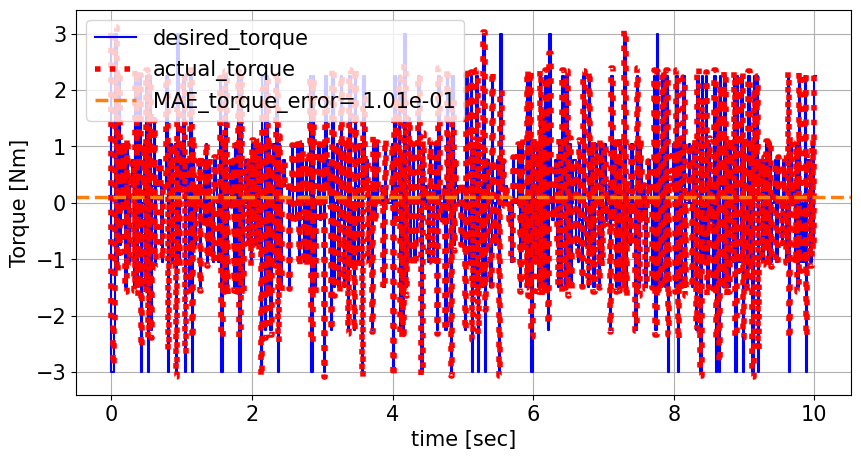

In [62]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [63]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

MAE torque error= 0.10122192603817894


In [64]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

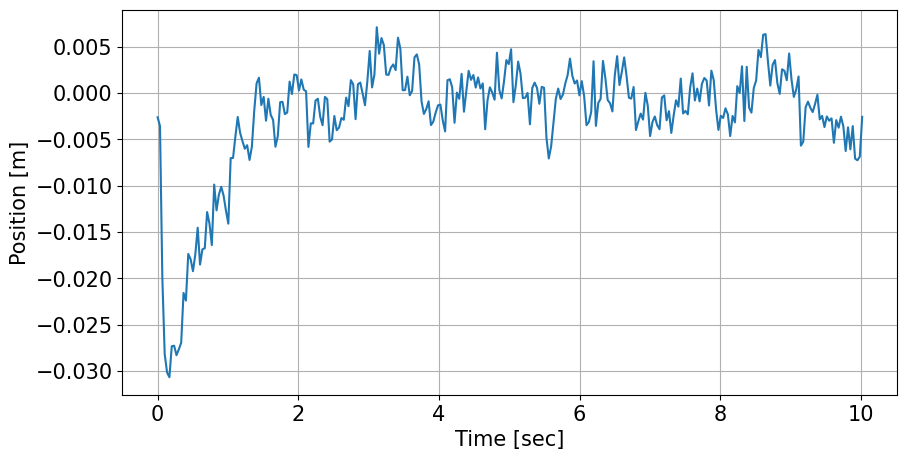

In [65]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [66]:
print(len(position))


501


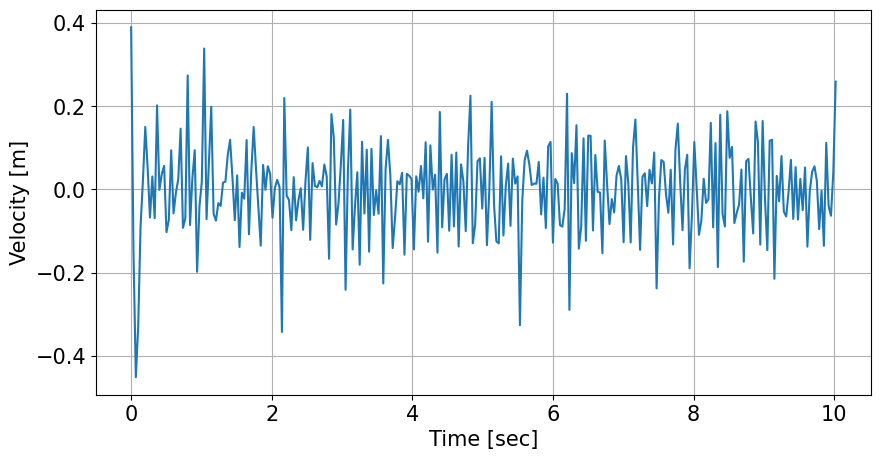

In [67]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

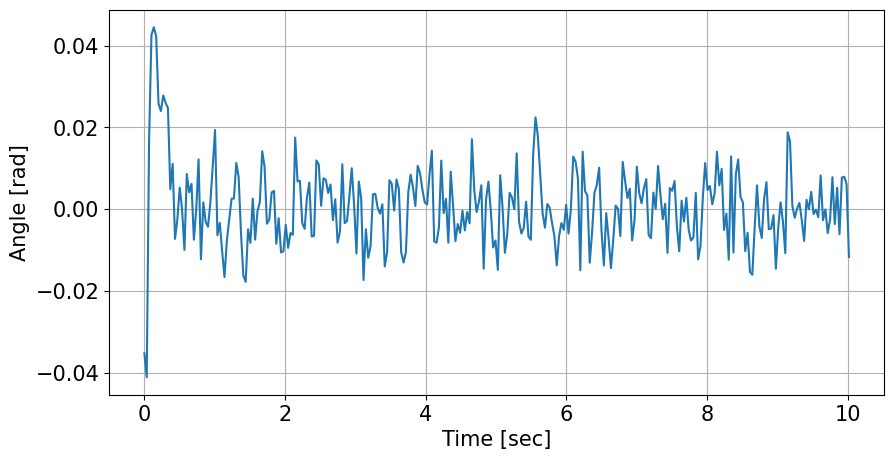

In [68]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

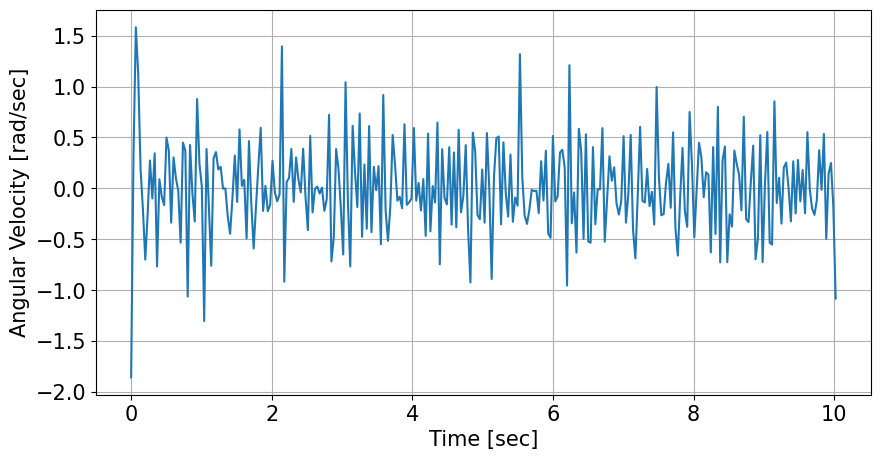

In [69]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

**Test Actual Env FF**

In [70]:
observation = env.reset()
total_episodes = 100
#train_mode = False
## for traingng of ideal: action_actual=action_desired_RL
#env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
env.ideal_env = False
env.DCMotorModel.Kp = 0.0
env.DCMotorModel.Ki = 0.0
env.DCMotorModel.Kd = 0.0
env.DCMotorModel.Kr = 1.0
env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
#env.ideal_env = False
#env.DCMotorModel.Kp = 4.3
#env.DCMotorModel.Ki = 1.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.7
#env.DCMotorModel.Kw = 1.0

In [71]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []

ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

save_observation = []
save_wanted_torque = []
save_actual_torque = []

num_success = 0
for ep in range(total_episodes):
  observation = env.reset()
  if ep==total_episodes-1:
    observation*=0
    observation[0]=1
  done=False
  t=0
  episodic_reward = 0
  episodic_abs_error_action = 0
  #n_count=1
  while not done and t<501:
      # using our observation, choose an action and take it in the environment
      # Get the logits, action, and take one step in the environment
      observation = observation.reshape(1, -1)
      logits, action = sample_action(observation)
      #observation_new, reward, done, _, _ = env.step(action[0].numpy())
      observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
      observation = observation_new
      if ep == total_episodes - 1:
        save_observation.append(observation)
        save_wanted_torque.append(torque_wanted)
        save_actual_torque.append(torque_actual)
      t+=1

      episodic_reward += reward
      if not env.ideal_env:
        episodic_abs_error_action += abs(torque_wanted-torque_actual)
        #episodic_abs_error_action += (abs(torque_wanted-torque_actual)-episodic_abs_error_action)/n_count
        #n_count+=1


  ep_reward_list.append(episodic_reward)

  # Mean of last 40 episodes
  avg_reward = np.mean(ep_reward_list[-40:])
  print("Episode * {} * Avg Reward is ==> {}".format(ep, f"{avg_reward:.2f}"))
  avg_reward_list.append(avg_reward)

  if not env.ideal_env:
    ep_abs_error_action_list.append(episodic_abs_error_action/t)
    avg_ep_abs_error = np.mean(ep_abs_error_action_list[-40:])
    print("Episode * {} * Avg Action Abs Error is ==> {}".format(ep, f"{avg_ep_abs_error:.2e}"))
    avg_ep_abs_error_action_list.append(avg_ep_abs_error)

  if done:
    print("Pole fell down during episode")
  else:
    print("Pole NOT fell down during episode")
  num_success += 0+(not done)

Episode * 0 * Avg Reward is ==> 471.24
Episode * 0 * Avg Action Abs Error is ==> 1.46e+00
Pole NOT fell down during episode
Episode * 1 * Avg Reward is ==> 473.95
Episode * 1 * Avg Action Abs Error is ==> 1.46e+00
Pole NOT fell down during episode
Episode * 2 * Avg Reward is ==> 476.05
Episode * 2 * Avg Action Abs Error is ==> 1.44e+00
Pole NOT fell down during episode
Episode * 3 * Avg Reward is ==> 476.66
Episode * 3 * Avg Action Abs Error is ==> 1.40e+00
Pole NOT fell down during episode
Episode * 4 * Avg Reward is ==> 476.29
Episode * 4 * Avg Action Abs Error is ==> 1.39e+00
Pole NOT fell down during episode
Episode * 5 * Avg Reward is ==> 476.61
Episode * 5 * Avg Action Abs Error is ==> 1.40e+00
Pole NOT fell down during episode
Episode * 6 * Avg Reward is ==> 476.45
Episode * 6 * Avg Action Abs Error is ==> 1.40e+00
Pole NOT fell down during episode
Episode * 7 * Avg Reward is ==> 476.11
Episode * 7 * Avg Action Abs Error is ==> 1.40e+00
Pole NOT fell down during episode
Episode 

In [72]:
score = num_success/total_episodes*100
print(f"score=({num_success} successes)/({total_episodes} episodes)*100={score:.1f}")

score=(100 successes)/(100 episodes)*100=100.0


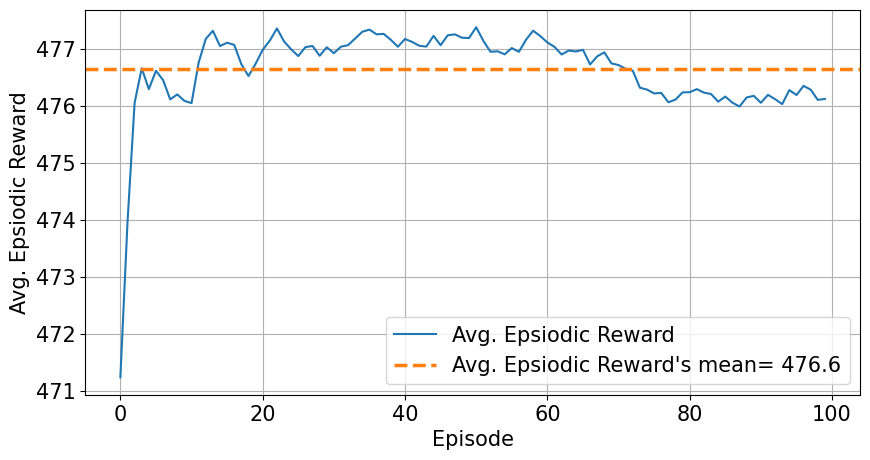

In [73]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [74]:
print("Avg. Epsiodic Reward's mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's mean=
476.6452348387926


In [75]:
dt=env.tau
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )


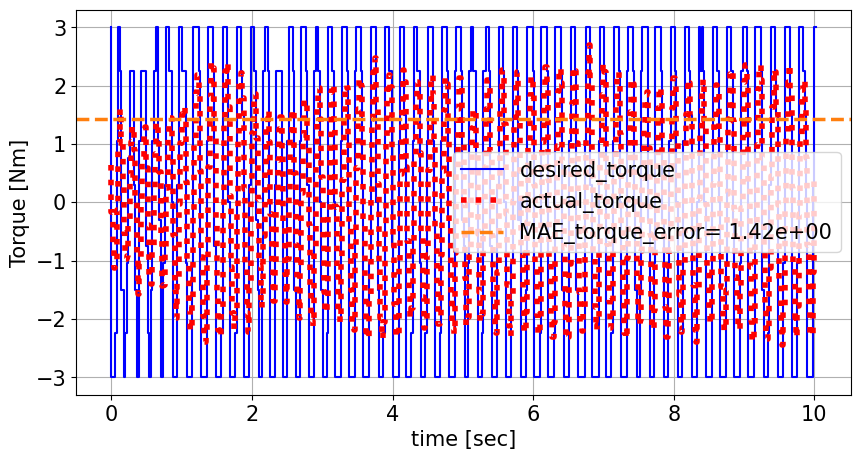

In [76]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_, save_wanted_torque ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_, save_actual_torque , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_wanted_torque)-np.array(save_actual_torque)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [77]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

MAE torque error= 1.4249096968610662


In [78]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

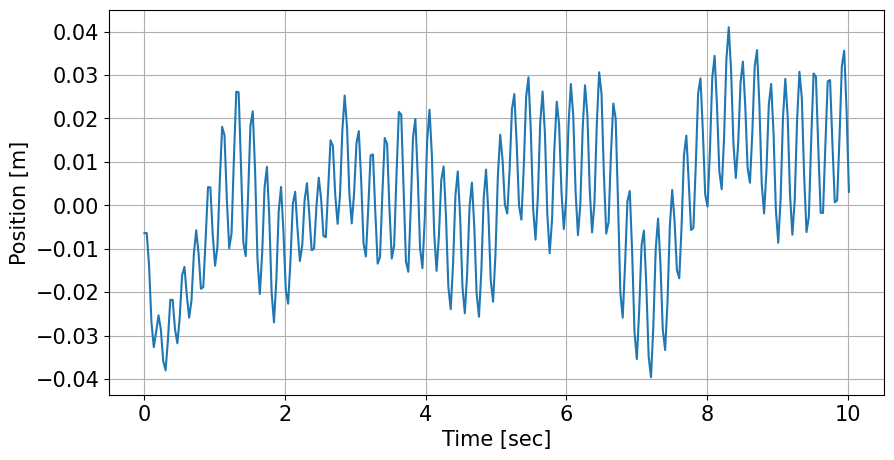

In [79]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.show()

In [80]:
print(len(position))


501


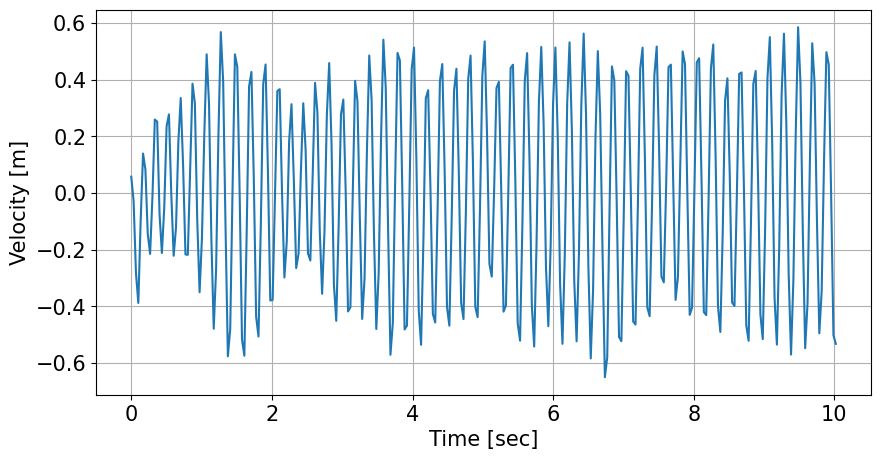

In [81]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m]')
plt.show()

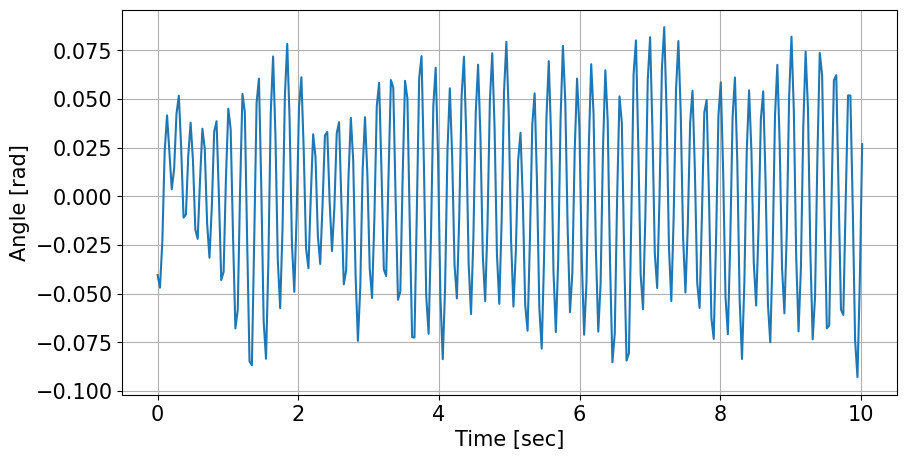

In [82]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.show()

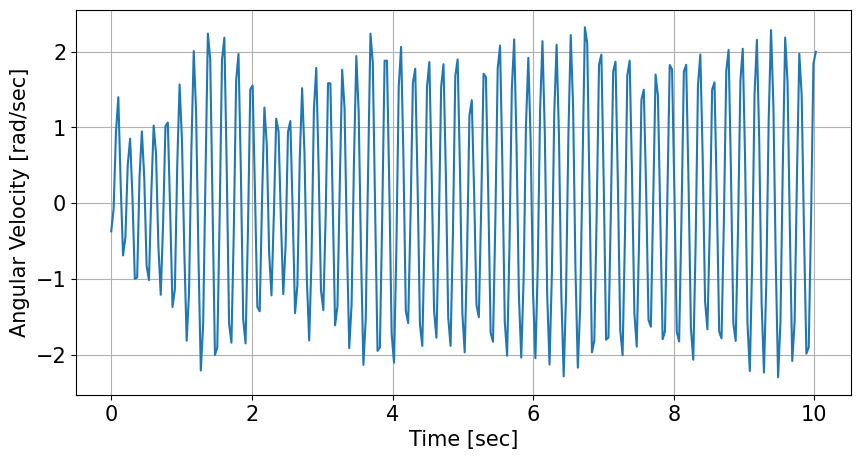

In [83]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()